In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from IPython.display import display
# import ace_tools as tools

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

from sklearn.feature_selection import RFECV
from sklearn.pipeline import make_pipeline

import seaborn as sns

from imblearn.over_sampling import BorderlineSMOTE


### import data

In [ ]:
df = pd.read_excel('Compost_Data.xlsx')

,Day,T,MC,pH,C/N Ratio,Ammonia,Nitrate,TN,TOC,EC,OM,T Value,GI,Maturity_Score
0,0,35.463,60.0000,5.7345,26.775500,2515.000000,325.49,1.80632,48.365121,1.784600,83.381469,1.000000,32.882100,28.042095
1,3,41.866,56.8814,7.1327,23.049400,3449.100000,302.42,1.92498,44.369634,2.436600,76.493249,0.860839,39.461500,36.185328
2,6,59.134,53.0847,7.9646,20.469700,5197.600000,243.40,1.83675,37.597721,3.011800,64.818472,0.764494,30.546900,37.074037
3,9,53.119,49.4237,8.1770,18.750000,1940.100000,203.99,1.78550,33.478125,3.156600,57.716287,0.700267,63.121900,51.246933
4,12,38.955,45.2203,8.0177,17.030300,814.400000,200.52,1.91893,32.679954,3.559600,56.340240,0.636040,79.469100,59.698282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,5,40.800,56.8008,7.3200,26.215385,522.903653,0.00,1.95000,51.120000,1.514333,86.820513,0.735261,73.389900,53.402808
448,10,17.600,45.5358,7.2300,17.751969,179.822071,0.00,2.54000,45.090000,1.387000,84.907598,0.497888,148.222222,89.720337
449,15,20.200,40.3880,7.4200,14.924242,146.696953,0.00,2.64000,39.400000,1.519000,83.511977,0.418579,118.222222,82.461888
450,20,20.700,40.3495,7.5300,13.865455,108.839674,0.00,2.75000,38.130000,1.631667,81.732816,0.388883,119.666929,84.213942


### class determination

In [11]:
def classify_maturity(row):
  if row["GI"] < 70:
    return "Immature"
  elif 70<= row["GI"] <= 80:
    return "Moderately Mature"
  else: 
    return "Mature"

df["Maturity_Class"] = df.apply(classify_maturity, axis=1)

### normalize data from 0 to 1

In [13]:
def scalled_data(df):
  df_new = df.drop(columns=["Maturity_Score", "GI","T Value", "Maturity_Class"])
  numerical_columns = df_new.select_dtypes(include=["float64", "int64"]).columns.tolist()
  scaler = MinMaxScaler(feature_range=(0, 1))
  df_norm = pd.DataFrame(scaler.fit_transform(df[numerical_columns]), columns=numerical_columns)
  df_scaled = pd.concat([df_norm.reset_index(drop=True), df['Maturity_Class']],axis=1)
  return df_scaled

In [15]:
df_scaled =scalled_data(df)

In [16]:
M_counts= df_scaled["Maturity_Class"].value_counts()
M_counts

Maturity_Class
Immature             226
Mature               188
Moderately Mature     38
Name: count, dtype: int64

In [17]:
stats_by_class = df.groupby("Maturity_Class").agg(["mean", "std"])
stats_by_class
stats_by_class.to_excel('class_description1.xlsx')

### spider chart

In [38]:
def spider_chart(df):
    
  df["Maturity_Class"] = df["Maturity_Class"].str.lower().str.strip()
  numerical_columns = df.select_dtypes(include=["float64", "int64"]).columns.tolist()
  grouped_data = df.groupby("Maturity_Class")[numerical_columns].mean()


  custom_order =["immature", "moderately mature", "mature"]
  grouped_data = grouped_data.loc[custom_order]

  labels = numerical_columns
  num_vars = len(labels)
  angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
  angles.append(angles[0])
  fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

  max_val = grouped_data.max().max()

  for maturity_class, values in grouped_data.iterrows():
        values = values.tolist()
        values.append(values[0])  
        ax.plot(angles, values, label=maturity_class, linewidth=2, linestyle="solid")
        ax.fill(angles, values, alpha=0.25)

  ax.set_xticks(angles[:-1])
  ax.set_xticklabels(labels, fontsize=20)
  ax.set_yticks([])
  ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=20)
  plt.show()

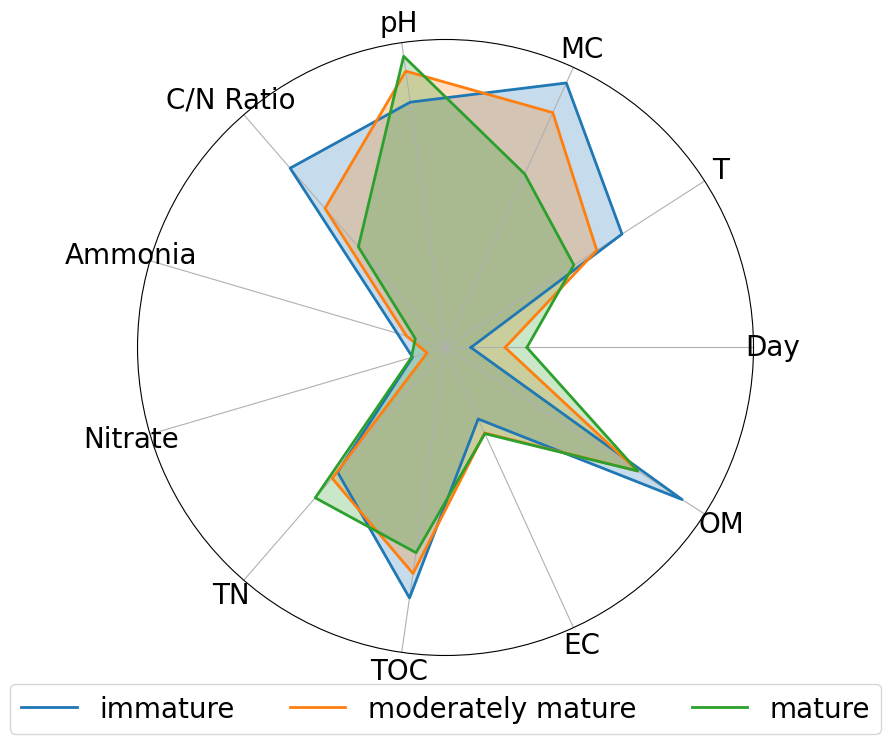

In [39]:
plot = spider_chart(df_scaled)

In [30]:
x_data=df_scaled.drop(columns=["Maturity_Class"])
y_data=df_scaled["Maturity_Class"]
blsmote = BorderlineSMOTE(sampling_strategy='not majority', kind='borderline-1', random_state=42)
X_data_blsmote, y_data_blsmote = blsmote.fit_resample(x_data, y_data)


print("Class distribution AFTER Borderline-SMOTE:")
print(y_data_blsmote.value_counts())

Class distribution AFTER Borderline-SMOTE:
Maturity_Class
immature             226
moderately mature    226
mature               226
Name: count, dtype: int64


### data split

In [31]:
def data_split(x_data, y_data):
    x_train, x_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.20, random_state=42)
    return x_train, x_test, y_train, y_test

x_train, x_test, y_train, y_test = data_split(X_data_blsmote, y_data_blsmote)


### grid hyperparameter search

In [ ]:
### GB model

x_train, y_train = make_classification(n_samples=542, n_features=11, random_state=42)
gb = GradientBoostingClassifier()
param_grid = {
    'n_estimators': [50, 100, 200], 
    'learning_rate': [0.01, 0.05, 0.1, 0.2],  
    'max_depth': [2, 3, 4, 5],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 3, 5],  
    'subsample': [0.6, 0.8, 1.0],  
    'max_features': ['sqrt', 'log2', None]  
}
grid_search = GridSearchCV(gb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 200, 'subsample': 0.8}
Best Accuracy: 0.9262487257900102


In [ ]:
# KNN
x_train, y_train = make_classification(n_samples=429, n_features=11, random_state=42)
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': list(range(1, 31)),  
    'weights': ['uniform', 'distance'],  
    'metric': ['euclidean', 'manhattan', 'minkowski'],  
    'p': [1, 2] 
}
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 10, 'p': 1, 'weights': 'uniform'}
Best Accuracy: 0.9743638850889192


In [ ]:
### SVM
svm = SVC()
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  
    'kernel': ['linear', 'rbf', 'poly'],  
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],  
    'degree': [2, 3, 4]  
}
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'C': 100, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}
Best Accuracy: 0.9906976744186047


c:\CICA_folder\PhD folder\phd_code\.venv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [ ]:
### DT
dt = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [3, 5, 10, None],  
    'min_samples_split': [2, 5, 10, 20],  
    'min_samples_leaf': [1, 3, 5, 10],  
    'max_features': ['sqrt', 'log2', None],  
    'criterion': ['gini', 'entropy']  
}
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best Accuracy: 0.9579480164158687


In [ ]:
### RF
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100, 200, 300],  
    'max_depth': [3, 5, 10, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 3, 5],  
    'max_features': ['sqrt', 'log2', None], 
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)
print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy:", grid_search.best_score_)

c:\CICA_folder\PhD folder\phd_code\.venv\Lib\site-packages\numpy\ma\core.py:2846: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'bootstrap': False, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best Accuracy: 0.9169554875976894


In [40]:
model_KNN = KNeighborsClassifier(metric='manhattan', n_neighbors=10, p=1, weights='uniform')
model_SVM =  SVC(C=100, degree=2, gamma=0.01, kernel='rbf')
model_GB = GradientBoostingClassifier(learning_rate=0.05, max_depth=5, max_features=None, min_samples_leaf=3, min_samples_split=10, n_estimators=200, subsample=0.8)
model_DT = DecisionTreeClassifier(criterion='entropy', max_depth=5, max_features=None, min_samples_leaf=1, min_samples_split=20)
model_RF = RandomForestClassifier (bootstrap=True, max_depth=10, max_features='sqrt', min_samples_leaf=1, min_samples_split=2, n_estimators=200)

### evaluation metrics

In [41]:
def eval_model(y_true, y_pred):
  class_labels = ["Mature", "Moderately Mature", "Immature"]
  precision = precision_score(y_true, y_pred, average='weighted')
  recall = recall_score(y_true, y_pred, average='weighted')
  f1 = f1_score(y_true, y_pred, average='weighted')
  accuracy = accuracy_score(y_true, y_pred)
  # cm = pd.DataFrame(confusion_matrix(y_true, y_pred), index=class_labels, columns=class_labels)
  
  return precision, recall, f1, accuracy

### cross validation

In [42]:
def cv_shuffle(x_data, y_data, model):
  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
  fold_scores=[]
  fold =1
  for train_idx, val_idx in cv.split(x_data, y_data):
      X_train, X_val = x_data.iloc[train_idx], x_data.iloc[val_idx]  
      y_train, y_val = y_data.iloc[train_idx], y_data.iloc[val_idx]

      model.fit(X_train, y_train)
      y_pred = model.predict(X_val)
      accuracy, precision, recall, f1 = eval_model(y_val, y_pred)
      fold_scores.append([fold, accuracy, precision, recall, f1])
      fold += 1
  fold_scores_df = pd.DataFrame(fold_scores, columns=["Fold", "Accuracy", "Precision", "Recall", "F1 Score"])
  return fold_scores_df

### confusion metrics

In [43]:
def plot_confusion_matrix(y_true, y_pred, class_labels):
    class_labels = [
        lbl if lbl != "moderately mature" else "moderately\nmature"
        for lbl in class_labels
    ]
    cm = confusion_matrix(y_true, y_pred)
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(6,5))
    ax = sns.heatmap(
        cm_percent,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        annot_kws={"fontsize": 20},
        vmin=0, vmax=100,
        cbar_kws={"ticks": [0,20,40,60,80,100]}
    )
    ax.set_xticklabels(class_labels, fontsize=16)
    ax.set_yticklabels(class_labels, fontsize=16)

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=18)

    plt.xlabel("Predicted label", fontsize=18)
    plt.ylabel("True label", fontsize=18)

    plt.tight_layout()
    plt.show()

### evaluate on training set

In [44]:
def evaluate_models(x_data, y_data):
    models = {
        "KNN": model_KNN,
        "SVM": model_SVM,
        "GB": model_GB,
        "DT": model_DT,
        "RF": model_RF
    }

    results = []

    for name, model in models.items():
        cv_results = cv_shuffle(x_data, y_data, model)

        avg_accuracy = cv_results["Accuracy"].mean()
        avg_precision = cv_results["Precision"].mean()
        avg_recall = cv_results["Recall"].mean()
        avg_f1 = cv_results["F1 Score"].mean()

        results.append({
            "Model": name,
            "Accuracy": avg_accuracy,
            "Precision": avg_precision,
            "Recall": avg_recall,
            "F1 Score": avg_f1
        })

    results_df = pd.DataFrame(results)

    return results_df

In [45]:
mean_score= evaluate_models(x_train, y_train)
mean_score

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN,0.856593,0.832144,0.833538,0.832144
1,SVM,0.783242,0.756439,0.758263,0.756439
2,GB,0.920934,0.917040,0.917306,0.917040
3,DT,0.809151,0.782263,0.781900,0.782263
4,RF,0.916529,0.909616,0.909674,0.909616


### test model on test set

In [47]:
def test_models_on_testset(X_train, y_train, X_test, y_test):
    models = {
        "KNN": model_KNN,
        "SVM": model_SVM,
        "GB": model_GB,
        "DT": model_DT,
        "RF": model_RF
    }

    results = []

    class_labels = ["immature", "moderately mature", "mature"]

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1-score": f1_score(y_test, y_pred, average="weighted"),
        })

        print(f"\n{name} Confusion Matrix:")
        plot_confusion_matrix(y_test, y_pred, class_labels)

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

    return df_results


KNN Confusion Matrix:


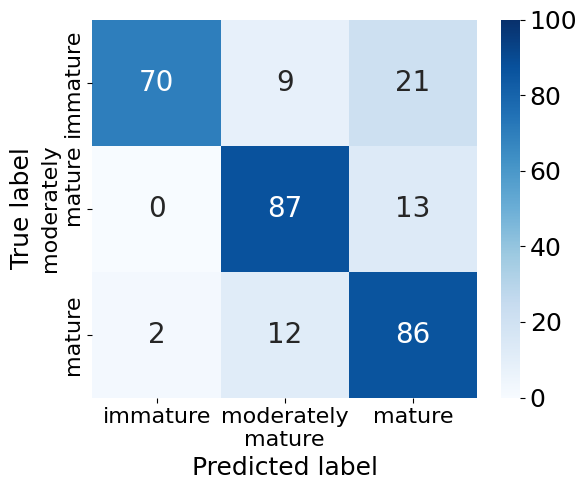


SVM Confusion Matrix:


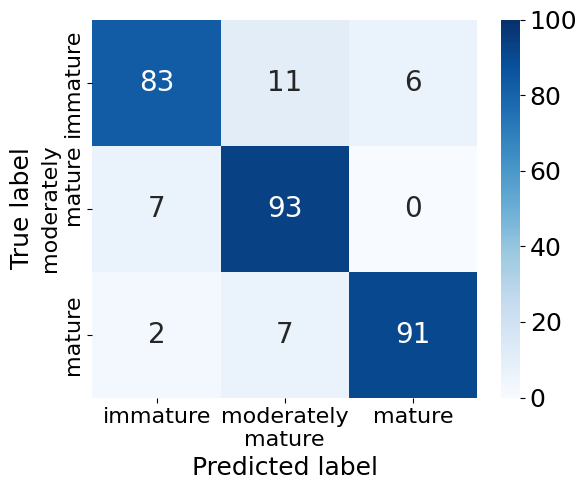


GB Confusion Matrix:


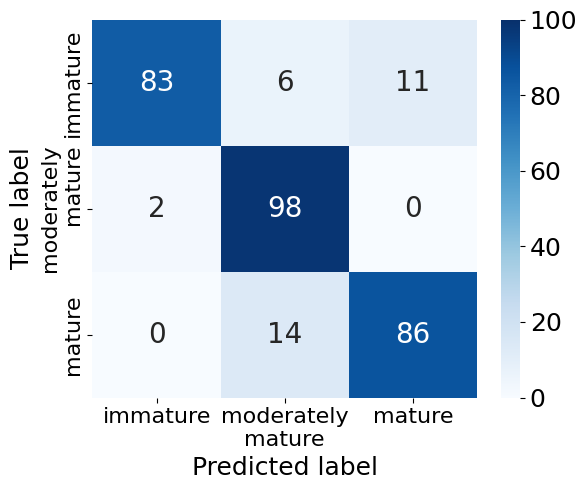


DT Confusion Matrix:


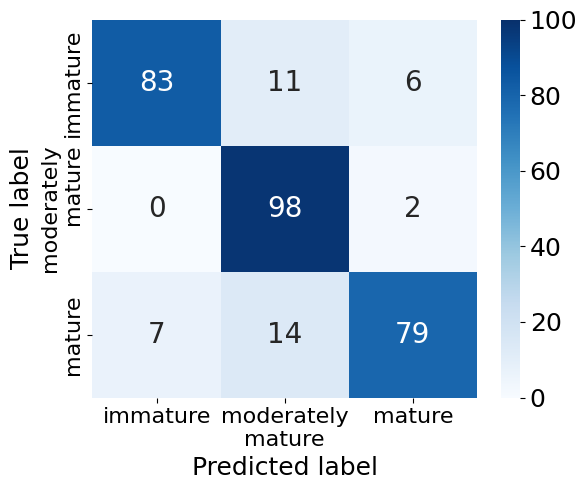


RF Confusion Matrix:


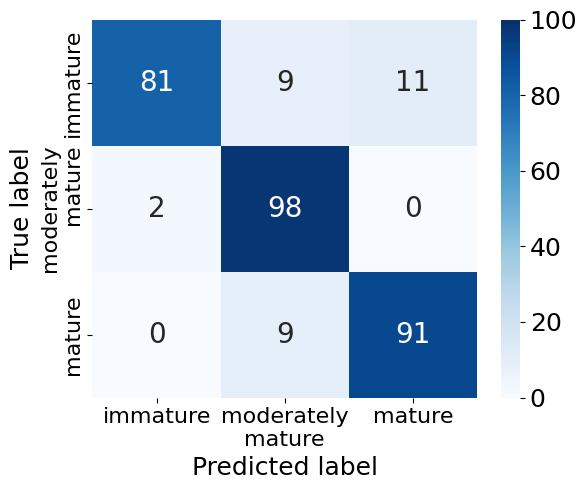

,Model,Accuracy,Precision,Recall,F1-score
0,RF,0.897059,0.904155,0.897059,0.896359
1,SVM,0.889706,0.892212,0.889706,0.889527
2,GB,0.889706,0.897348,0.889706,0.889509
3,DT,0.867647,0.875594,0.867647,0.866750
4,KNN,0.808824,0.832261,0.808824,0.810139


In [343]:
metric_score = test_models_on_testset(x_train, y_train, x_test, y_test)
metric_score

In [76]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

def recursive_feature_addition(x_data, y_data, model):
    scaler = StandardScaler()
    x_data_scaled = pd.DataFrame(scaler.fit_transform(x_data), columns=x_data.columns)

    x_train, x_test, y_train, y_test = train_test_split(x_data_scaled, y_data, test_size=0.2, random_state=42, stratify=y_data)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score_data = []
    selected_features = []
    remaining_features = list(x_train.columns)

    while len(remaining_features) > 0:
        best_feature = None
        best_score = 0

        for feature in remaining_features:
            temp_features = selected_features + [feature]
            scores = cross_val_score(model, x_train[temp_features], y_train, cv=skf, scoring="accuracy", n_jobs=-1)
            mean_score = scores.mean()

            if mean_score > best_score:
                best_score = mean_score
                best_feature = feature

        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        score_data.append([len(selected_features), best_score, best_feature])

    scores_df = pd.DataFrame(score_data, columns=["Number of Features", "Cross-Validation Accuracy", "Added Feature"])

    plt.figure(figsize=(8, 6))
    plt.plot(scores_df["Number of Features"], scores_df["Cross-Validation Accuracy"], marker="o", linestyle="--")
    plt.xlabel("Number of Features", fontsize=12)
    plt.ylabel("Cross-Validation Accuracy", fontsize=12)
    plt.title("Recursive Feature Addition", fontsize=14)
    plt.grid(True)
    plt.show()

    return scores_df


In [48]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

def recursive_feature_addition(x_data, y_data, model):
    scaler = StandardScaler()
    x_data_scaled = pd.DataFrame(scaler.fit_transform(x_data), columns=x_data.columns)

    # x_train, x_test, y_train, y_test = train_test_split(x_data_scaled, y_data, test_size=0.2, random_state=42, stratify=y_data)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    score_data = []
    selected_features = []
    remaining_features = list(x_train.columns)

    while len(remaining_features) > 0:
        best_feature = None
        best_score = 0

        for feature in remaining_features:
            temp_features = selected_features + [feature]
            scores = cross_val_score(model, x_data_scaled[temp_features], y_data, cv=skf, scoring="accuracy", n_jobs=-1)
            mean_score = scores.mean()

            if mean_score > best_score:
                best_score = mean_score
                best_feature = feature

        selected_features.append(best_feature)
        remaining_features.remove(best_feature)
        score_data.append([len(selected_features), best_score, best_feature])

    scores_df = pd.DataFrame(score_data, columns=["Number of Features", "Cross-Validation Accuracy", "Added Feature"])

    plt.figure(figsize=(8, 6))
    plt.plot(scores_df["Number of Features"], scores_df["Cross-Validation Accuracy"], marker="o", linestyle="--")
    plt.xlabel("Number of Features", fontsize=12)
    plt.ylabel("Cross-Validation Accuracy", fontsize=12)
    plt.title("Recursive Feature Addition", fontsize=14)
    plt.grid(True)
    plt.show()

    return scores_df


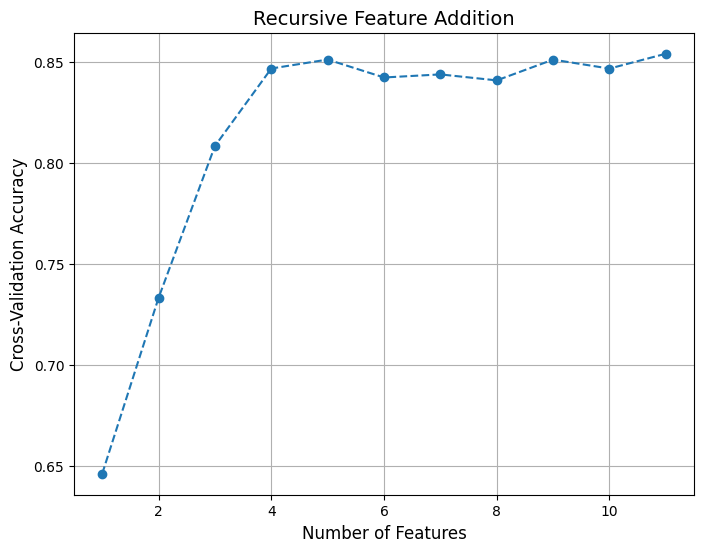

,Number of Features,Cross-Validation Accuracy,Added Feature
0,1,0.646078,Day
1,2,0.733170,TN
2,3,0.808355,OM
3,4,0.846710,Nitrate
4,5,0.851144,TOC
5,6,0.842266,MC
6,7,0.843791,C/N Ratio
7,8,0.840828,Ammonia
8,9,0.851111,EC
9,10,0.846678,T


In [49]:
df_score_KNN = recursive_feature_addition(X_data_blsmote, y_data_blsmote, model_KNN)
df_score_KNN

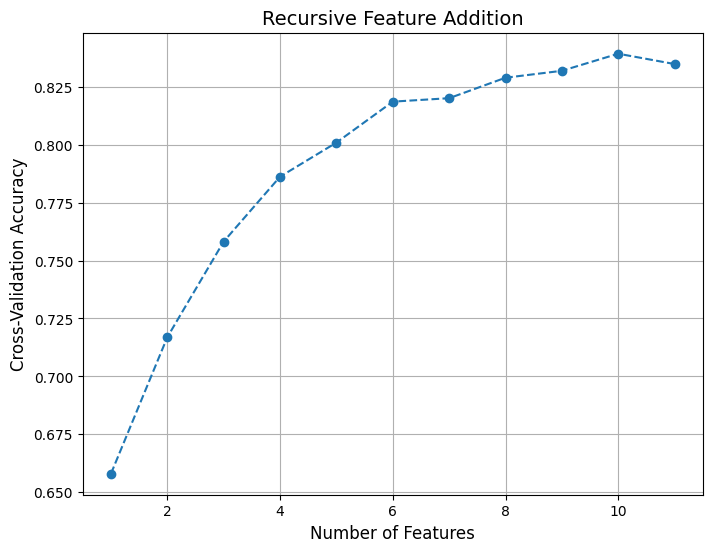

,Number of Features,Cross-Validation Accuracy,Added Feature
0,1,0.657996,C/N Ratio
1,2,0.716928,Ammonia
2,3,0.758214,MC
3,4,0.786209,OM
4,5,0.800926,TN
5,6,0.818606,Nitrate
6,7,0.820098,EC
7,8,0.828932,T
8,9,0.831917,pH
9,10,0.839292,TOC


In [50]:
df_score_SVM = recursive_feature_addition(X_data_blsmote, y_data_blsmote, model_SVM)
df_score_SVM

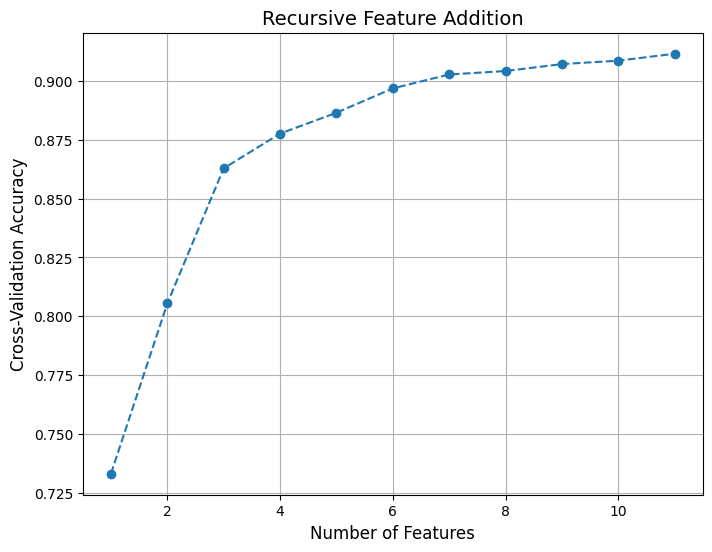

,Number of Features,Cross-Validation Accuracy,Added Feature
0,1,0.733115,Day
1,2,0.805436,Nitrate
2,3,0.862821,MC
3,4,0.877582,TN
4,5,0.886460,OM
5,6,0.896786,pH
6,7,0.902702,TOC
7,8,0.904172,Ammonia
8,9,0.907124,T
9,10,0.908573,EC


In [51]:
df_score_GB = recursive_feature_addition(X_data_blsmote, y_data_blsmote, model_GB)
df_score_GB

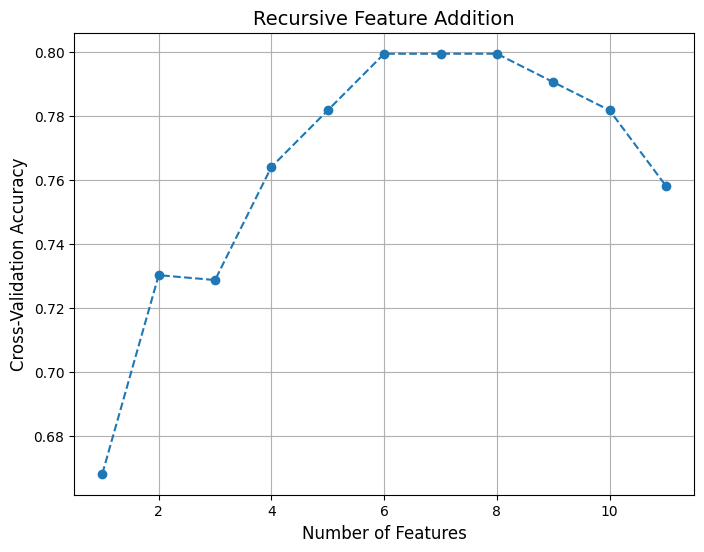

,Number of Features,Cross-Validation Accuracy,Added Feature
0,1,0.668137,Day
1,2,0.730229,TN
2,3,0.728704,C/N Ratio
3,4,0.764085,Nitrate
4,5,0.781786,Ammonia
5,6,0.799466,OM
6,7,0.799477,pH
7,8,0.799477,TOC
8,9,0.790599,T
9,10,0.781765,EC


In [52]:
df_score_DT = recursive_feature_addition(X_data_blsmote, y_data_blsmote, model_DT)
df_score_DT

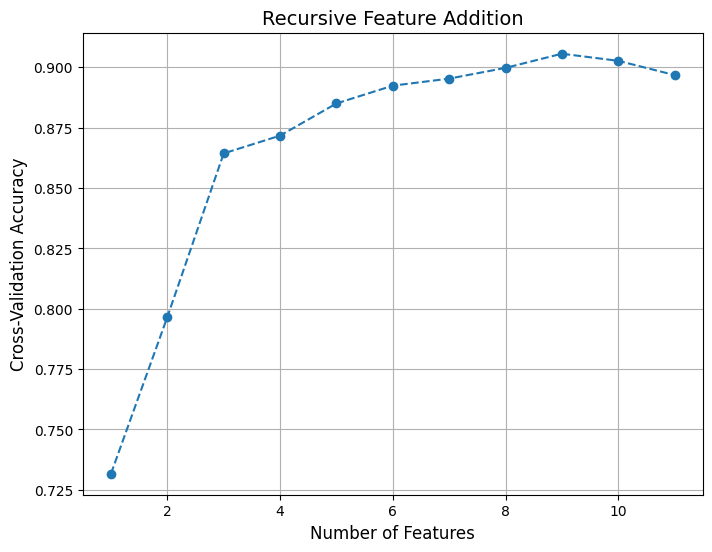

,Number of Features,Cross-Validation Accuracy,Added Feature
0,1,0.731645,Day
1,2,0.796547,Nitrate
2,3,0.864357,TN
3,4,0.871710,Ammonia
4,5,0.885044,TOC
5,6,0.892418,T
6,7,0.895338,pH
7,8,0.899782,OM
8,9,0.905654,EC
9,10,0.902712,C/N Ratio


In [53]:
df_score_RF = recursive_feature_addition(X_data_blsmote, y_data_blsmote, model_RF)
df_score_RF

In [54]:
df_RFA = pd.concat([df_score_KNN, df_score_SVM, df_score_GB, df_score_DT, df_score_RF], axis=1).drop(columns=["Number of Features"])
df_RFA.to_excel('cross validation accuracy.xlsx')

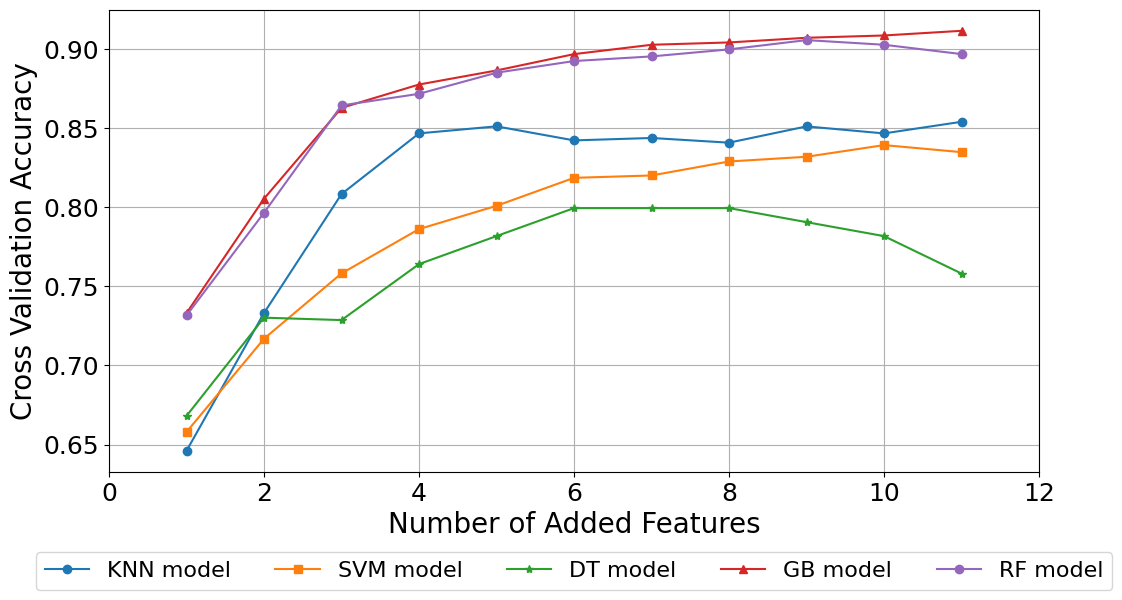

In [ ]:
x = df_score_KNN["Number of Features"]
y1 = df_score_KNN["Cross-Validation Accuracy"]
y2 = df_score_SVM["Cross-Validation Accuracy"]
y3 = df_score_GB["Cross-Validation Accuracy"]
y4 = df_score_DT["Cross-Validation Accuracy"]
y5 = df_score_RF["Cross-Validation Accuracy"]

plt.figure(figsize=(12, 6))

plt.plot(x, y1, label='KNN model', linestyle='-', marker='o')
plt.plot(x, y2, label='SVM model', linestyle='-', marker='s')
plt.plot(x, y4, label='DT model', linestyle='-', marker='*')
plt.plot(x, y3, label='GB model', linestyle='-', marker='^')
plt.plot(x, y5, label='RF model', linestyle='-', marker='o')


plt.xlabel('Number of Added Features', fontsize=20)
plt.ylabel('Cross Validation Accuracy', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlim(0,12)

plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=16)
plt.grid(True)
plt.show()